In [1]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

In [208]:
df_credits = pd.read_csv('data/credits.csv')
df_movies = pd.read_csv('data/movies_metadata.csv')
df_ratings = pd.read_csv('data/ratings.csv')
df_keywords = pd.read_csv('data/keywords.csv')
df_links = pd.read_csv('data/links.csv')

/var/folders/3s/0c70tlj57zd6hjlvvtwxz_h80000gp/T/ipykernel_95226/917720018.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_movies = pd.read_csv('data/movies_metadata.csv')


In [209]:
print('credits cols: ' + df_credits.columns)
print('movie cols: ' + df_movies.columns)
print('ratings cols: ' + df_ratings.columns)
print('keywords cols: ' + df_keywords.columns)
print('links cols: ' + df_links.columns)

Index(['credits cols: cast', 'credits cols: crew', 'credits cols: id'], dtype='object')
Index(['movie cols: adult', 'movie cols: belongs_to_collection',
       'movie cols: budget', 'movie cols: genres', 'movie cols: homepage',
       'movie cols: id', 'movie cols: imdb_id',
       'movie cols: original_language', 'movie cols: original_title',
       'movie cols: overview', 'movie cols: popularity',
       'movie cols: poster_path', 'movie cols: production_companies',
       'movie cols: production_countries', 'movie cols: release_date',
       'movie cols: revenue', 'movie cols: runtime',
       'movie cols: spoken_languages', 'movie cols: status',
       'movie cols: tagline', 'movie cols: title', 'movie cols: video',
       'movie cols: vote_average', 'movie cols: vote_count'],
      dtype='object')
Index(['ratings cols: userId', 'ratings cols: movieId', 'ratings cols: rating',
       'ratings cols: timestamp'],
      dtype='object')
Index(['keywords cols: id', 'keywords cols: keywo

In [210]:
df_movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [211]:
df_credits.head()


,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [212]:
df_keywords.head()

,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


In [213]:
df_links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [214]:
df_ratings.head()

,userId,movieId,rating,timestamp
0,1,110,1.0,1425941529
1,1,147,4.5,1425942435
2,1,858,5.0,1425941523
3,1,1221,5.0,1425941546
4,1,1246,5.0,1425941556


In [270]:
df_movies['id'] = pd.to_numeric(df_movies['id'], errors='coerce')
df_movies = df_movies.dropna(subset=['id']).astype({'id': 'int64'})

df_links['tmdbId'] = pd.to_numeric(df_links['tmdbId'], errors='coerce')
df_links = df_links.dropna(subset=['tmdbId']).astype({'tmdbId': 'int64'})


df_ratings_agg = df_ratings.groupby('movieId')['rating'].mean().reset_index()
df_inter = df_ratings_agg.merge(df_links, left_on='movieId', right_on='movieId', how='inner')


df_merged = df_movies.merge(df_credits, left_on='id', right_on='id', how='inner')
df_merged = df_merged.merge(df_keywords, left_on='id', right_on='id', how='inner')

df_merged = df_inter.merge(df_merged, left_on='tmdbId', right_on='id', how='inner')

In [271]:

df_merged[df_merged['id'] == 862]

,movieId,rating,imdbId,tmdbId,adult,belongs_to_collection,budget,genres,homepage,id,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,crew,keywords
0,1,3.888157,114709,862,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."


In [229]:
df_merged.columns

Index(['movieId', 'rating', 'imdbId', 'tmdbId', 'adult',
       'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count', 'cast', 'crew', 'keywords'],
      dtype='object')

In [272]:
def get_list(x):
    # 1. Se for nulo ou não for string, retorna vazio
    if pd.isna(x) or not isinstance(x, str):
        return []
    
    try:
        # 2. Transforma a string "[{'name': 'Tom Hanks'...}]" em uma LISTA real
        data = ast.literal_eval(x)
        
        # 3. Agora que é uma lista, extraímos os nomes
        if isinstance(data, list):
            names = [i['name'] for i in data]
            # Retorna apenas os 3 primeiros para manter o modelo leve
            return names[:3]
            
    except (ValueError, SyntaxError):
        # Caso a string esteja corrompida
        return []
        
    return []

# Aplicando nos Gêneros, Keywords e Elenco
df_merged['genres'] = df_merged['genres'].apply(get_list)
df_merged['keywords'] = df_merged['keywords'].apply(get_list)
df_merged['cast'] = df_merged['cast'].apply(get_list)

In [276]:
df_merged['keywords']

0                                     [jealousy, toy, boy]
1        [board game, disappearance, based on children'...
2             [fishing, best friend, duringcreditsstinger]
3        [based on novel, interracial relationship, sin...
4                       [baby, midlife crisis, confidence]
                               ...                        
46160                                                   []
46161                                        [tragic love]
46162                                [artist, play, pinoy]
46163                                                   []
46164                                                   []
Name: keywords, Length: 46165, dtype: object

In [277]:
def get_director(x):
    # 1. Verifica se o valor é nulo ou não é string
    if pd.isna(x) or not isinstance(x, str):
        return "Unknown"
    
    try:
        # 2. Transforma a string "[{'job': 'Director', ...}]" em uma lista real
        data = ast.literal_eval(x)
        
        # 3. Itera na lista de dicionários
        for i in data:
            if i.get('job') == 'Director':
                return i.get('name')
                
    except (ValueError, SyntaxError):
        # Caso a string esteja mal formatada
        return "Unknown"
        
    return "Unknown"

df_merged['director'] = df_merged['crew'].apply(get_director)

In [278]:
df_merged['director']

0           John Lasseter
1            Joe Johnston
2           Howard Deutch
3         Forest Whitaker
4           Charles Shyer
               ...       
46160          John Irvin
46161    Hamid Nematollah
46162            Lav Diaz
46163      Mark L. Lester
46164    Yakov Protazanov
Name: director, Length: 46165, dtype: object

In [233]:
print("\nMédia de nota - Diretor Unknown:")
print(df_merged[df_merged['director'] == 'Unknown']['vote_average'].mean())

print("\nQuantidade de filmes Unknown:")
print(len(df_merged[df_merged['director'] == 'Unknown']))


Média de nota - Diretor Unknown:
3.9909395973154362

Quantidade de filmes Unknown:
894


In [234]:
len(df_merged[df_merged['vote_count'] > 50])

9251

In [279]:
df = df_merged

### EDA

Top 15 colunas com maior % de valores ausentes:
belongs_to_collection    90.15
homepage                 82.72
tagline                  55.39
overview                  2.12
poster_path               0.84
runtime                   0.57
release_date              0.19
status                    0.18
imdb_id                   0.04
original_language         0.02
revenue                   0.01
production_countries      0.01
popularity                0.01
production_companies      0.01
title                     0.01


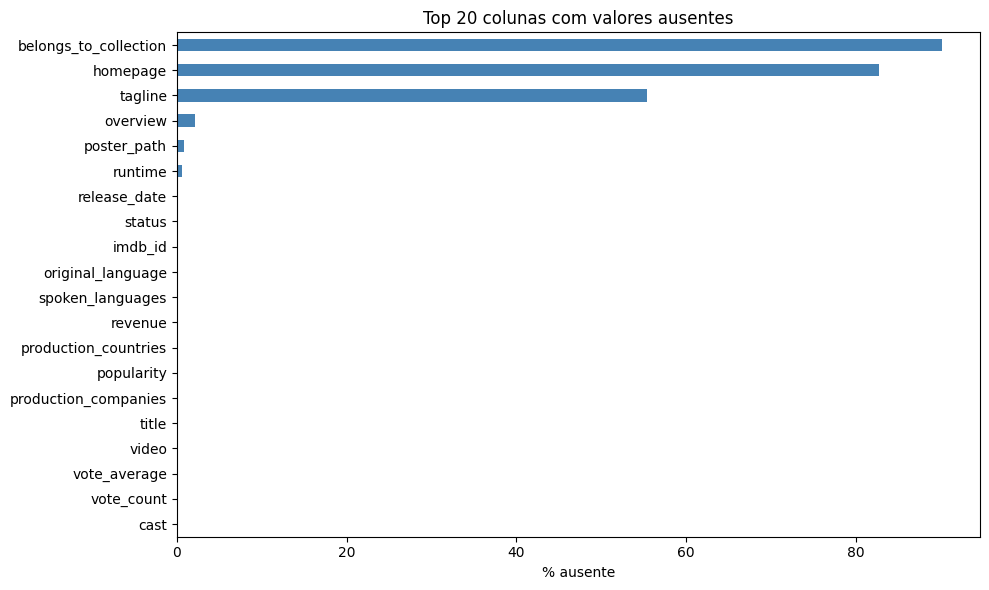


Linhas com id duplicado: 1455
Linhas com imdb_id duplicado (exceto NaN): 1471

adult — value counts:
adult
False    46156
True         9
Name: count, dtype: int64

video — value counts:
video
False    46067
True        94
NaN          4
Name: count, dtype: int64

Nota média/mediana por adult:
           mean  median  count
adult                         
False  5.644824     6.0  46152
True   3.922222     4.0      9


In [236]:
# --- Qualidade de dados: ausentes, duplicatas, flags ---
miss_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Top 15 colunas com maior % de valores ausentes:")
print(miss_pct.head(15).round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
miss_pct.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% ausente')
ax.set_title('Top 20 colunas com valores ausentes')
plt.tight_layout()
plt.show()

# Duplicatas de chaves
id_dup = df['id'].duplicated().sum()
imdb_dup = df['imdb_id'].duplicated().sum() if 'imdb_id' in df.columns else None
print(f"\nLinhas com id duplicado: {id_dup}")
if imdb_dup is not None:
    print(f"Linhas com imdb_id duplicado (exceto NaN): {df['imdb_id'].duplicated().sum()}")

# adult / video (sanidade TMDB)
if 'adult' in df.columns:
    print("\nadult — value counts:")
    print(df['adult'].value_counts(dropna=False))
if 'video' in df.columns:
    print("\nvideo — value counts:")
    print(df['video'].value_counts(dropna=False))

if 'adult' in df.columns and 'vote_average' in df.columns:
    va = pd.to_numeric(df['vote_average'], errors='coerce')
    g = df.assign(_va=va).groupby(df['adult'], dropna=False)['_va'].agg(['mean', 'median', 'count'])
    print("\nNota média/mediana por adult:")
    print(g)


/var/folders/3s/0c70tlj57zd6hjlvvtwxz_h80000gp/T/ipykernel_95226/1458666681.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=bin_percentages.index, y=bin_percentages.values, palette='magma')


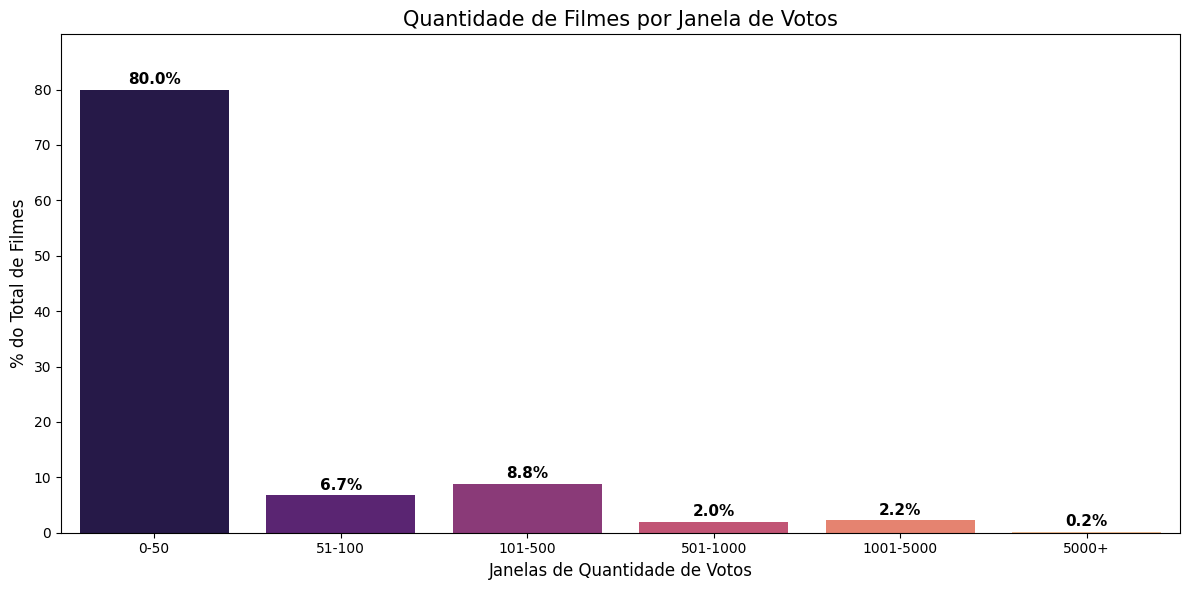

In [237]:
bins = [0, 50, 100, 500, 1000, 5000, df_merged['vote_count'].max()]
labels = ['0-50', '51-100', '101-500', '501-1000', '1001-5000', '5000+']


df['vote_bins'] = pd.cut(df['vote_count'], bins=bins, labels=labels, include_lowest=True)
bin_percentages = (df['vote_bins'].value_counts(normalize=True).sort_index()) * 100


plt.figure(figsize=(12, 6))
ax = sns.barplot(x=bin_percentages.index, y=bin_percentages.values, palette='magma')

# Estética do gráfico
plt.title('Quantidade de Filmes por Janela de Votos', fontsize=15)
plt.xlabel('Janelas de Quantidade de Votos', fontsize=12)
plt.ylabel('% do Total de Filmes', fontsize=12)

# Adicionar os números exatos em cima das barras
for i, v in enumerate(bin_percentages.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

# Ajustar o limite do eixo Y para dar espaço aos rótulos
plt.ylim(0, bin_percentages.max() + 10)

plt.tight_layout()
plt.show()

/var/folders/3s/0c70tlj57zd6hjlvvtwxz_h80000gp/T/ipykernel_95226/182078257.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['avg_bins'] = pd.cut(df_plot['vote_average'], bins=bins, labels=labels, include_lowest=True)
/var/folders/3s/0c70tlj57zd6hjlvvtwxz_h80000gp/T/ipykernel_95226/182078257.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=avg_percentages.index, y=avg_percentages.values, palette='coolwarm')


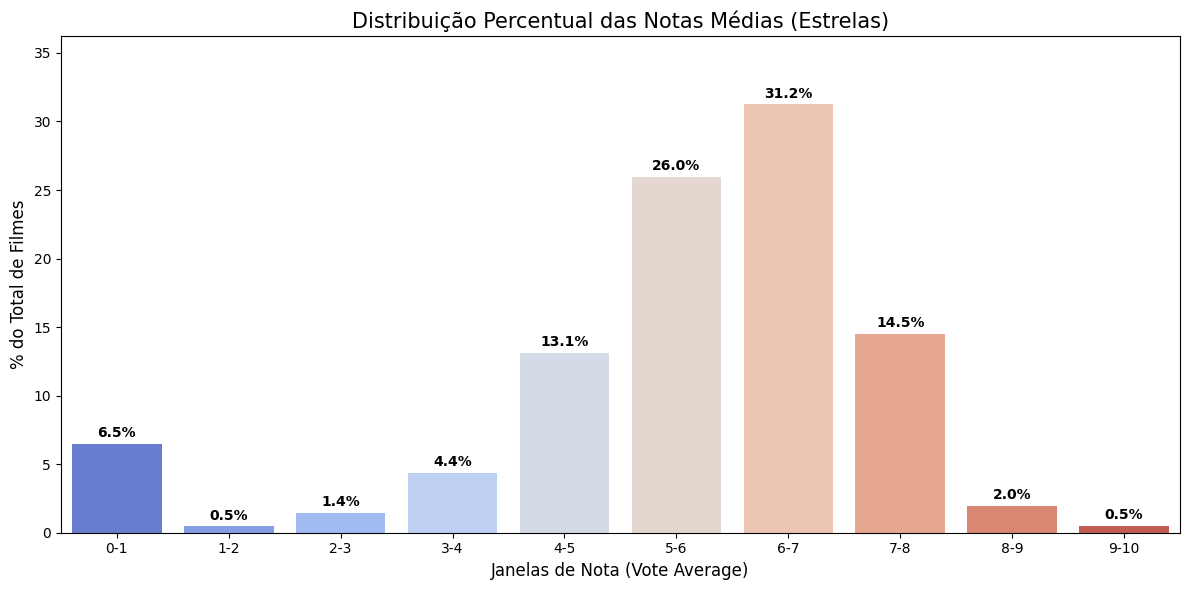

In [238]:
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')
df_plot = df.dropna(subset=['vote_average'])

# 2. Definir as janelas (bins) de 0 a 10
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8', '8-9', '9-10']

# Criar a coluna de categorias
df_plot['avg_bins'] = pd.cut(df_plot['vote_average'], bins=bins, labels=labels, include_lowest=True)

# 3. Calcular a Porcentagem
avg_percentages = (df_plot['avg_bins'].value_counts(normalize=True).sort_index()) * 100

# 4. Gerar o gráfico
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=avg_percentages.index, y=avg_percentages.values, palette='coolwarm')

# Estética e Rótulos
plt.title('Distribuição Percentual das Notas Médias (Estrelas)', fontsize=15)
plt.xlabel('Janelas de Nota (Vote Average)', fontsize=12)
plt.ylabel('% do Total de Filmes', fontsize=12)

# Adicionar o símbolo de % em cima das barras
for i, v in enumerate(avg_percentages.values):
    if v > 0: # Só mostra se a barra não for zero
        plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

# Ajustar o limite do eixo Y
plt.ylim(0, avg_percentages.max() + 5)

plt.tight_layout()
plt.show()

In [28]:
df['vote_count'].describe()

count    46624.000000
mean       108.169719
std        486.429314
min          0.000000
25%          3.000000
50%         10.000000
75%         34.000000
max      14075.000000
Name: vote_count, dtype: float64

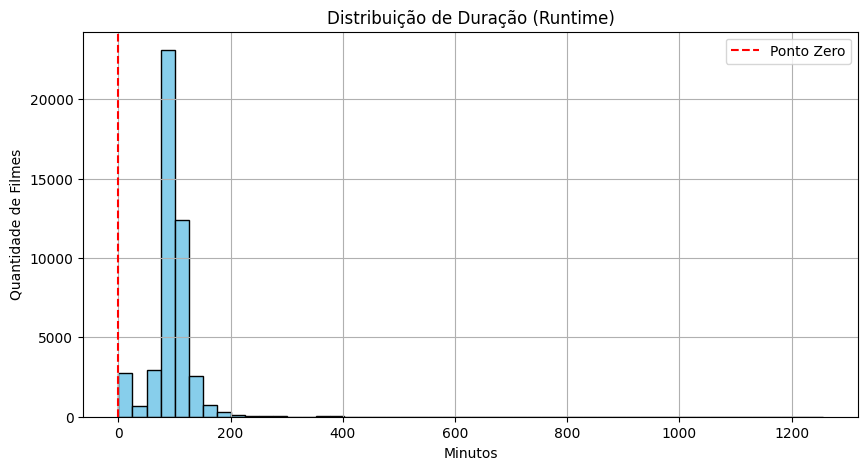

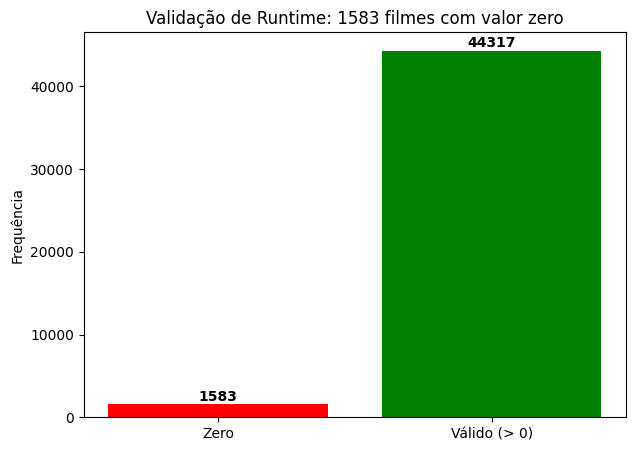

Valores nulos (NaN) em runtime: 265


In [239]:

# 1. Histograma para ver a distribuição geral e onde os zeros se encaixam
plt.figure(figsize=(10, 5))
df['runtime'].hist(bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Ponto Zero')
plt.title('Distribuição de Duração (Runtime)')
plt.xlabel('Minutos')
plt.ylabel('Quantidade de Filmes')
plt.legend()
plt.show()

# 2. Gráfico de barras comparativo (Zero vs. Não-Zero)
zeros = (df['runtime'] == 0).sum()
nao_zeros = (df['runtime'] > 0).sum()

plt.figure(figsize=(7, 5))
plt.bar(['Zero', 'Válido (> 0)'], [zeros, nao_zeros], color=['red', 'green'])
plt.title(f'Validação de Runtime: {zeros} filmes com valor zero')
plt.ylabel('Frequência')

# Adiciona os números exatos sobre as barras
for i, v in enumerate([zeros, nao_zeros]):
    plt.text(i, v + (nao_zeros * 0.01), str(v), ha='center', fontweight='bold')

plt.show()

# Verificação extra: quantos são nulos (NaN)?
print(f"Valores nulos (NaN) em runtime: {df['runtime'].isna().sum()}")

In [241]:
# 1. Forçar a conversão para numérico (o que não for número vira NaN automaticamente)
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')

# 2. Garantir que zeros e valores negativos virem NaN
# (O HistGradientBoosting lida com NaNs, mas se perde com zeros no log)
df['budget_clean'] = df['budget'].replace(0, np.nan)

# 3. Aplicar o log1p (Log de 1 + x) de forma segura
# O log1p ignora os NaNs e retorna NaN para eles, o que é perfeito para o seu modelo
df['log_budget'] = np.log1p(df['budget_clean'])

# 4. Verificação rápida
print(f"Sucesso! Zeros ou Erros convertidos em NaN: {df['log_budget'].isna().sum()}")
print(f"Média do log_budget: {df['log_budget'].mean():.2f}")

Sucesso! Zeros ou Erros convertidos em NaN: 37058
Média do log_budget: 15.34


🎬 Filmes com orçamento igual a zero: 37058 (80.27%)


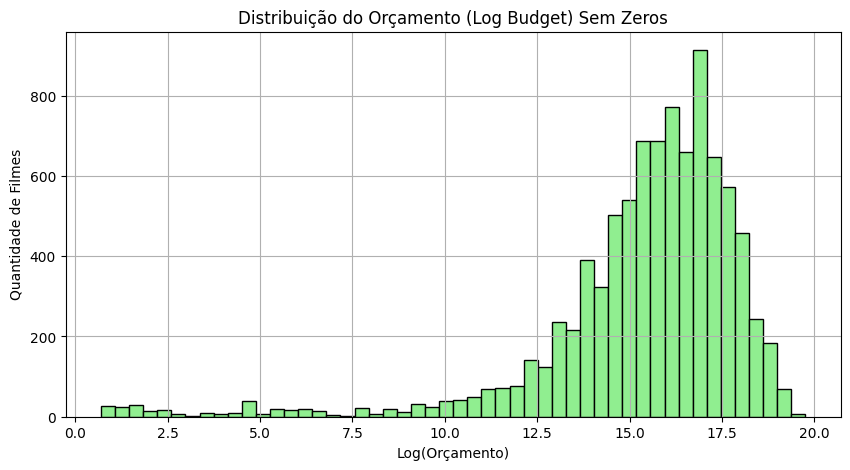

In [242]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Verificar quantos zeros temos no budget REAL (antes do log)
# Se você já tiver apenas a coluna 'log_budget', procure por valores <= 0 ou -inf
zeros_budget = (df['budget'] == 0).sum()
percentual = (zeros_budget / len(df)) * 100

print(f"🎬 Filmes com orçamento igual a zero: {zeros_budget} ({percentual:.2f}%)")

# 2. Corrigir os zeros (Substituindo por NaN)
# O HistGradientBoosting lida nativamente com NaN!
df['budget_corrigido'] = df['budget'].replace(0, np.nan)

# 3. Aplicar o Logaritmo APENAS nos valores maiores que zero
df['log_budget'] = np.log1p(df['budget_corrigido']) # log1p calcula log(1 + x) para evitar log(0)

# 4. Plotar a nova distribuição para garantir que está limpa
plt.figure(figsize=(10, 5))
df['log_budget'].hist(bins=50, color='lightgreen', edgecolor='black')
plt.title('Distribuição do Orçamento (Log Budget) Sem Zeros')
plt.xlabel('Log(Orçamento)')
plt.ylabel('Quantidade de Filmes')
plt.show()

### Filtrando filmes com mais de 50 votos

In [280]:
# Filtra filmes com mais de 50 votos (ajuste conforme achar melhor)
df_filtered = df[df['vote_count'] > 50].copy()

# Garante que colunas numéricas estejam no formato correto
df_filtered['budget'] = pd.to_numeric(df_filtered['budget'], errors='coerce')
df_filtered['vote_average'] = pd.to_numeric(df_filtered['vote_average'], errors='coerce')

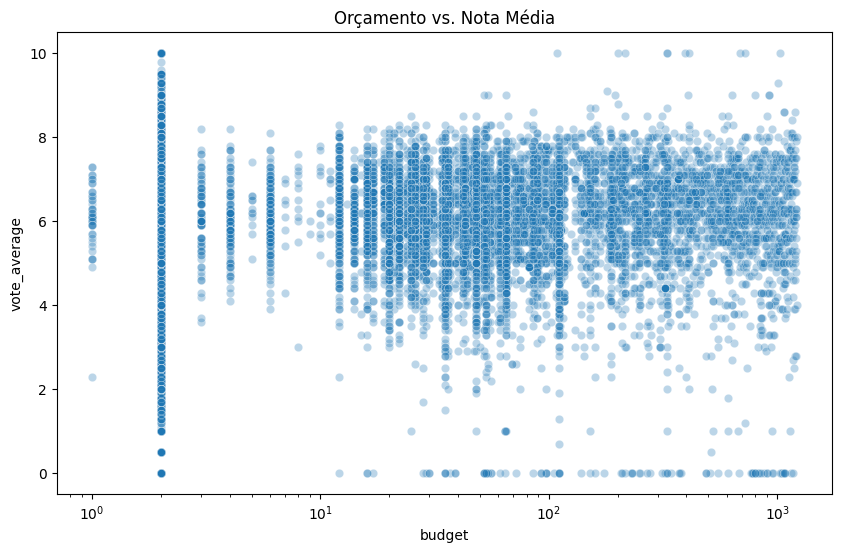

Correlação: 0.07


In [281]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='budget', y='vote_average', data=df, alpha=0.3)
plt.title('Orçamento vs. Nota Média')
plt.xscale('log') # Escala logarítmica ajuda a ver melhor os dados
plt.show()

# Verificando a correlação numérica
print(f"Correlação: {df['budget'].corr(df['vote_average']):.2f}")

/var/folders/3s/0c70tlj57zd6hjlvvtwxz_h80000gp/T/ipykernel_95226/2198460498.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors['vote_average'], y=top_directors.index, palette='magma')


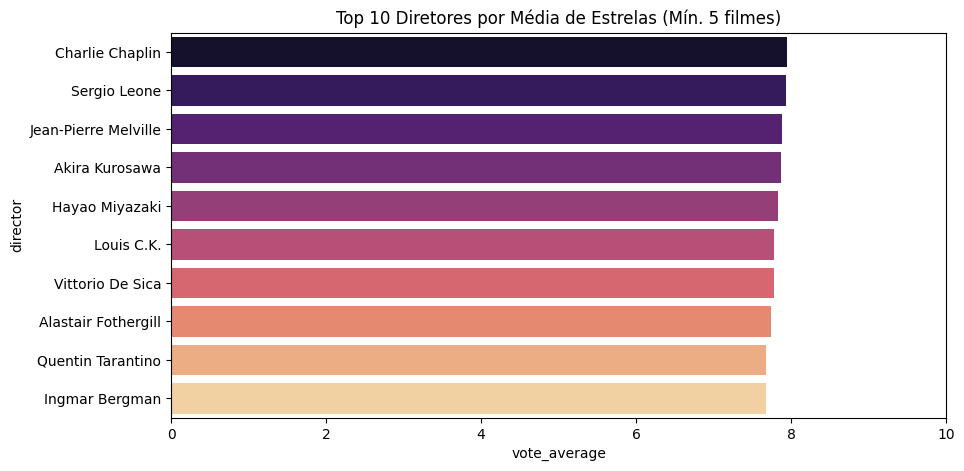

In [247]:
dir_stats = df_filtered.groupby('director').agg({'vote_average': 'mean', 'title': 'count'})

# Filtra diretores com mais de 5 filmes e pega os 10 melhores
top_directors = dir_stats[dir_stats['title'] >= 5].sort_values('vote_average', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_directors['vote_average'], y=top_directors.index, palette='magma')
plt.title('Top 10 Diretores por Média de Estrelas (Mín. 5 filmes)')
plt.xlim(0, 10)
plt.show()

/var/folders/3s/0c70tlj57zd6hjlvvtwxz_h80000gp/T/ipykernel_95226/1862846276.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


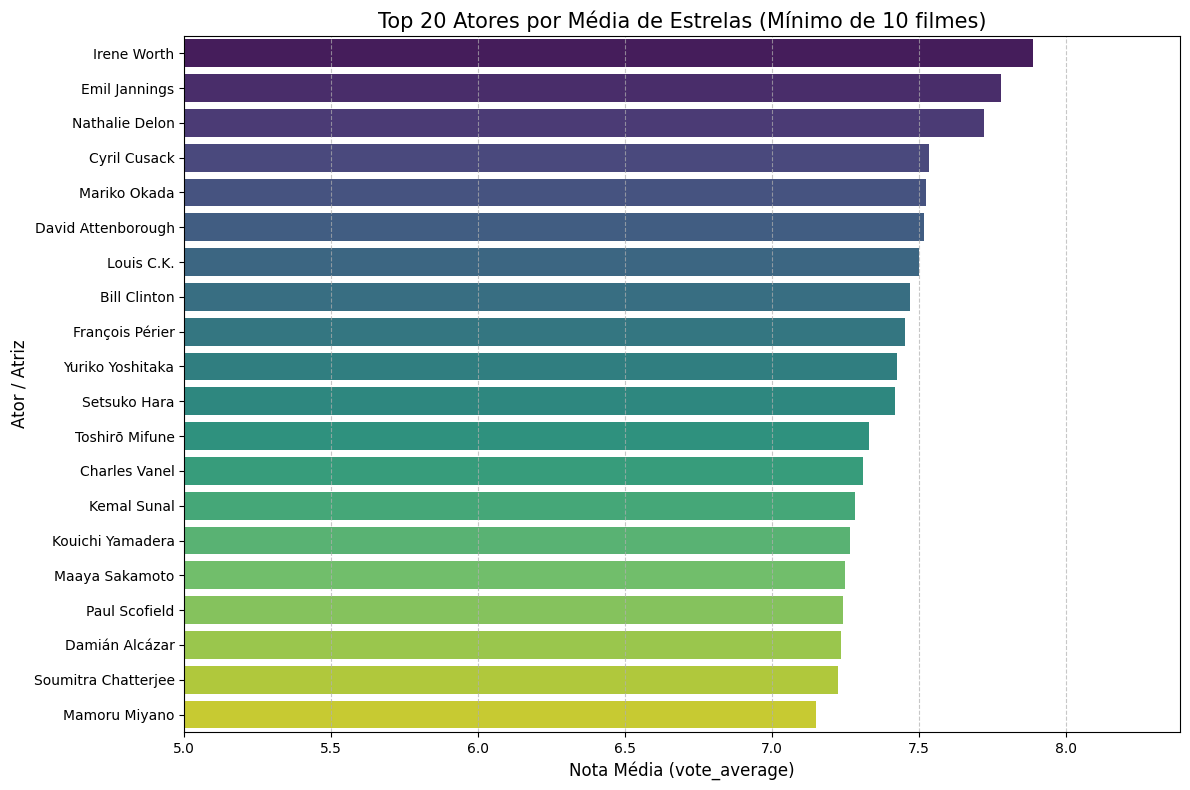

In [282]:

cast_expl = df.explode('cast')

actor_stats = cast_expl.groupby('cast').agg({
    'vote_average': 'mean',
    'title': 'count'
}).rename(columns={'title': 'movie_count'})

min_movies = 10
top_actors = actor_stats[actor_stats['movie_count'] >= min_movies].sort_values('vote_average', ascending=False).head(20)

# 4. Gerar o gráfico
plt.figure(figsize=(12, 8))
sns.barplot(
    x=top_actors['vote_average'], 
    y=top_actors.index, 
    palette='viridis'
)

plt.title(f'Top 20 Atores por Média de Estrelas (Mínimo de {min_movies} filmes)', fontsize=15)
plt.xlabel('Nota Média (vote_average)', fontsize=12)
plt.ylabel('Ator / Atriz', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Ajustar o limite do eixo X para destacar as diferenças entre as notas altas (ex: de 5 a 9)
plt.xlim(5, top_actors['vote_average'].max() + 0.5)

plt.tight_layout()
plt.show()

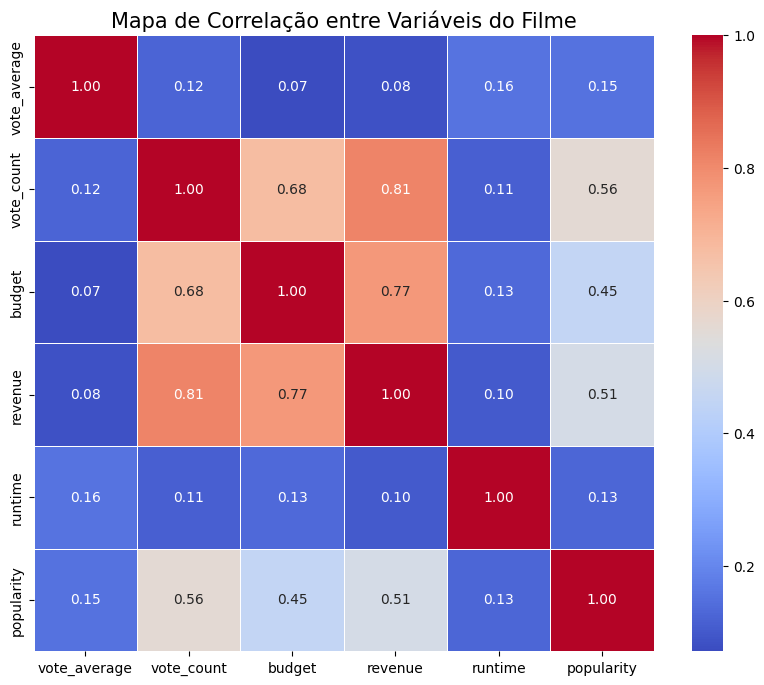

In [283]:
cols_to_corr = ['vote_average', 'vote_count', 'budget', 'revenue', 'runtime', 'popularity']
df_corr = df[cols_to_corr].apply(pd.to_numeric, errors='coerce')

corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Correlação entre Variáveis do Filme', fontsize=15)
plt.show()

Filmes com vote_count > 50: 9251
  + runtime > 0: 9203 (99.5%)
  + budget > 0: 5442 (58.8%)
  + revenue > 0: 5466 (59.1%)
  + budget e revenue > 0: 4446 (48.1%)


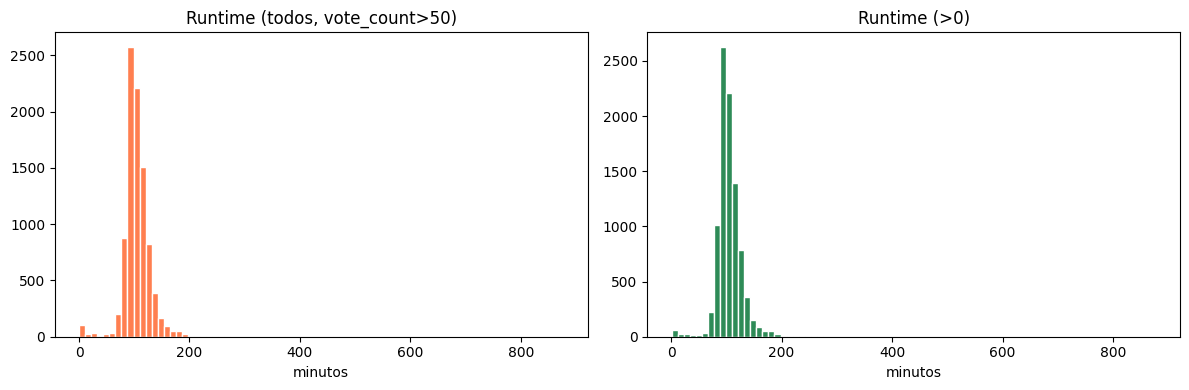

In [252]:
# --- Quantos filmes passam filtros típicos de modelagem (subconjunto >50 votos) ---
base = df_filtered.copy()
base['revenue'] = pd.to_numeric(base['revenue'], errors='coerce')
base['runtime'] = pd.to_numeric(base['runtime'], errors='coerce')
base['popularity'] = pd.to_numeric(base['popularity'], errors='coerce')

n0 = len(base)
n_runtime = (base['runtime'] > 0).sum()
n_budget = (base['budget'] > 0).sum()
n_rev = (base['revenue'] > 0).sum()
n_both = ((base['budget'] > 0) & (base['revenue'] > 0)).sum()

print(f"Filmes com vote_count > 50: {n0}")
print(f"  + runtime > 0: {n_runtime} ({100*n_runtime/n0:.1f}%)")
print(f"  + budget > 0: {n_budget} ({100*n_budget/n0:.1f}%)")
print(f"  + revenue > 0: {n_rev} ({100*n_rev/n0:.1f}%)")
print(f"  + budget e revenue > 0: {n_both} ({100*n_both/n0:.1f}%)")

# Histogramas runtime antes/depois de filtrar runtime > 0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(base['runtime'].dropna(), bins=80, color='coral', edgecolor='white')
axes[0].set_title('Runtime (todos, vote_count>50)')
axes[0].set_xlabel('minutos')

axes[1].hist(base.loc[base['runtime'] > 0, 'runtime'], bins=80, color='seagreen', edgecolor='white')
axes[1].set_title('Runtime (>0)')
axes[1].set_xlabel('minutos')
plt.tight_layout()
plt.show()


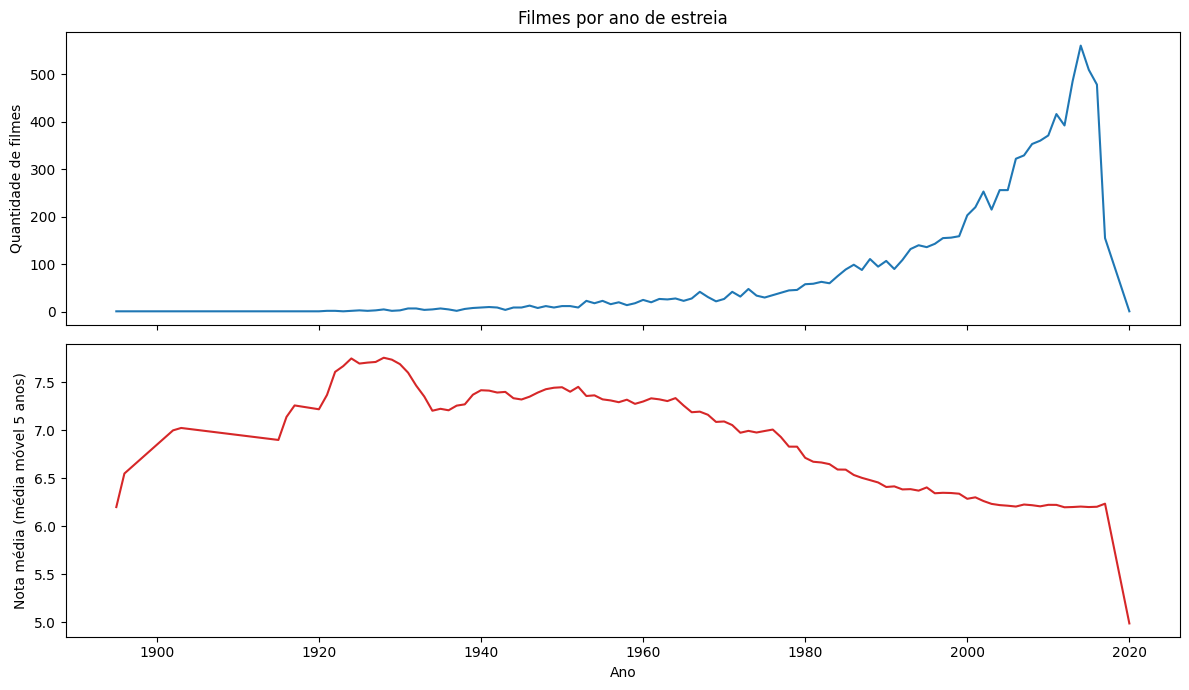

/var/folders/3s/0c70tlj57zd6hjlvvtwxz_h80000gp/T/ipykernel_95226/650393042.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_stats.index, y=month_stats['mean'], ax=ax, palette='Blues_d')


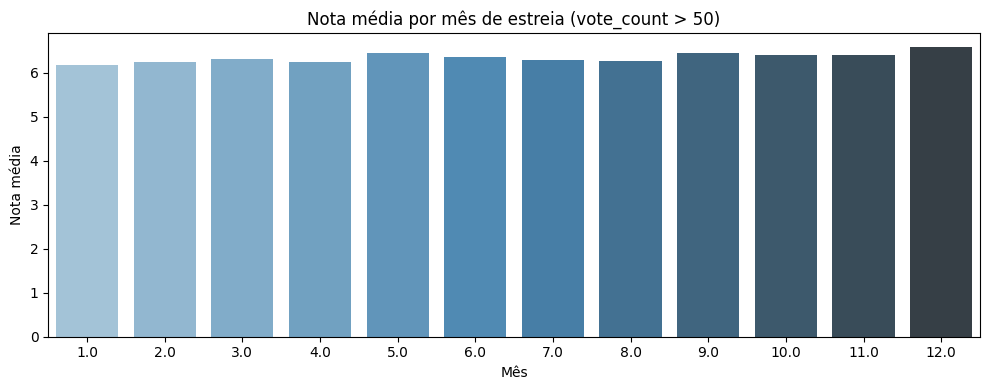

In [253]:
# --- Tempo: ano de lançamento e sazonalidade (mês) ---
eda_time = df_filtered.copy()
eda_time['release_dt'] = pd.to_datetime(eda_time['release_date'], errors='coerce')
eda_time['year'] = eda_time['release_dt'].dt.year
eda_time['month'] = eda_time['release_dt'].dt.month

# Filmes por ano
by_year = eda_time.dropna(subset=['year']).groupby('year').agg(
    n_films=('title', 'count'),
    mean_vote=('vote_average', 'mean'),
)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
by_year['n_films'].plot(ax=axes[0], color='tab:blue')
axes[0].set_ylabel('Quantidade de filmes')
axes[0].set_title('Filmes por ano de estreia')

by_year['mean_vote'].rolling(5, min_periods=1).mean().plot(ax=axes[1], color='tab:red')
axes[1].set_ylabel('Nota média (média móvel 5 anos)')
axes[1].set_xlabel('Ano')
plt.tight_layout()
plt.show()

# Heatmap: mês × média de nota (e contagem)
month_stats = eda_time.dropna(subset=['month']).groupby('month')['vote_average'].agg(['mean', 'count'])
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=month_stats.index, y=month_stats['mean'], ax=ax, palette='Blues_d')
ax.set_xlabel('Mês')
ax.set_ylabel('Nota média')
ax.set_title('Nota média por mês de estreia (vote_count > 50)')
plt.tight_layout()
plt.show()


Assimetria e curtose:
          runtime  popularity  vote_count  budget  revenue
skew        5.420      22.949       4.893   3.149    5.632
kurtosis  102.343     857.779      32.800  12.825   51.075


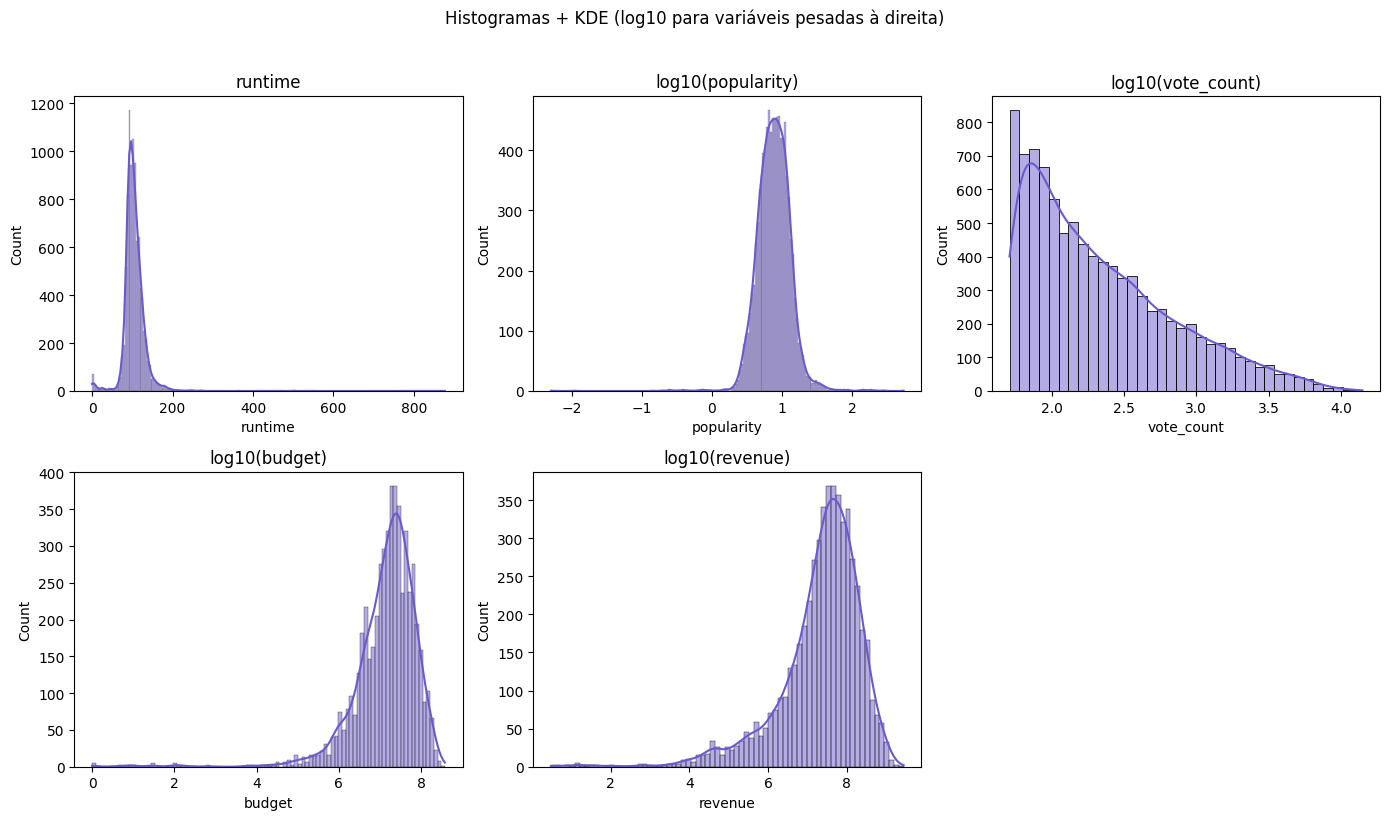

In [254]:
# --- Distribuições, assimetria e caudas (variáveis numéricas principais) ---
import numpy as np

num_cols = ['runtime', 'popularity', 'vote_count', 'budget', 'revenue']
dist_df = df_filtered.copy()
for c in num_cols:
    dist_df[c] = pd.to_numeric(dist_df[c], errors='coerce')

sk = dist_df[num_cols].apply(lambda s: pd.Series({
    'skew': s.skew(skipna=True),
    'kurtosis': s.kurtosis(skipna=True),
}))
print("Assimetria e curtose:")
print(sk.round(3))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    data = dist_df[col].dropna()
    if col in ('budget', 'revenue', 'popularity', 'vote_count') and len(data):
        data = data[data > 0]
        plot_vals = np.log10(data)
        title = f'log10({col})'
    else:
        plot_vals = data
        title = col
    sns.histplot(plot_vals, kde=True, ax=axes[i], color='slateblue')
    axes[i].set_title(title)
axes[5].axis('off')
plt.suptitle('Histogramas + KDE (log10 para variáveis pesadas à direita)', y=1.02)
plt.tight_layout()
plt.show()


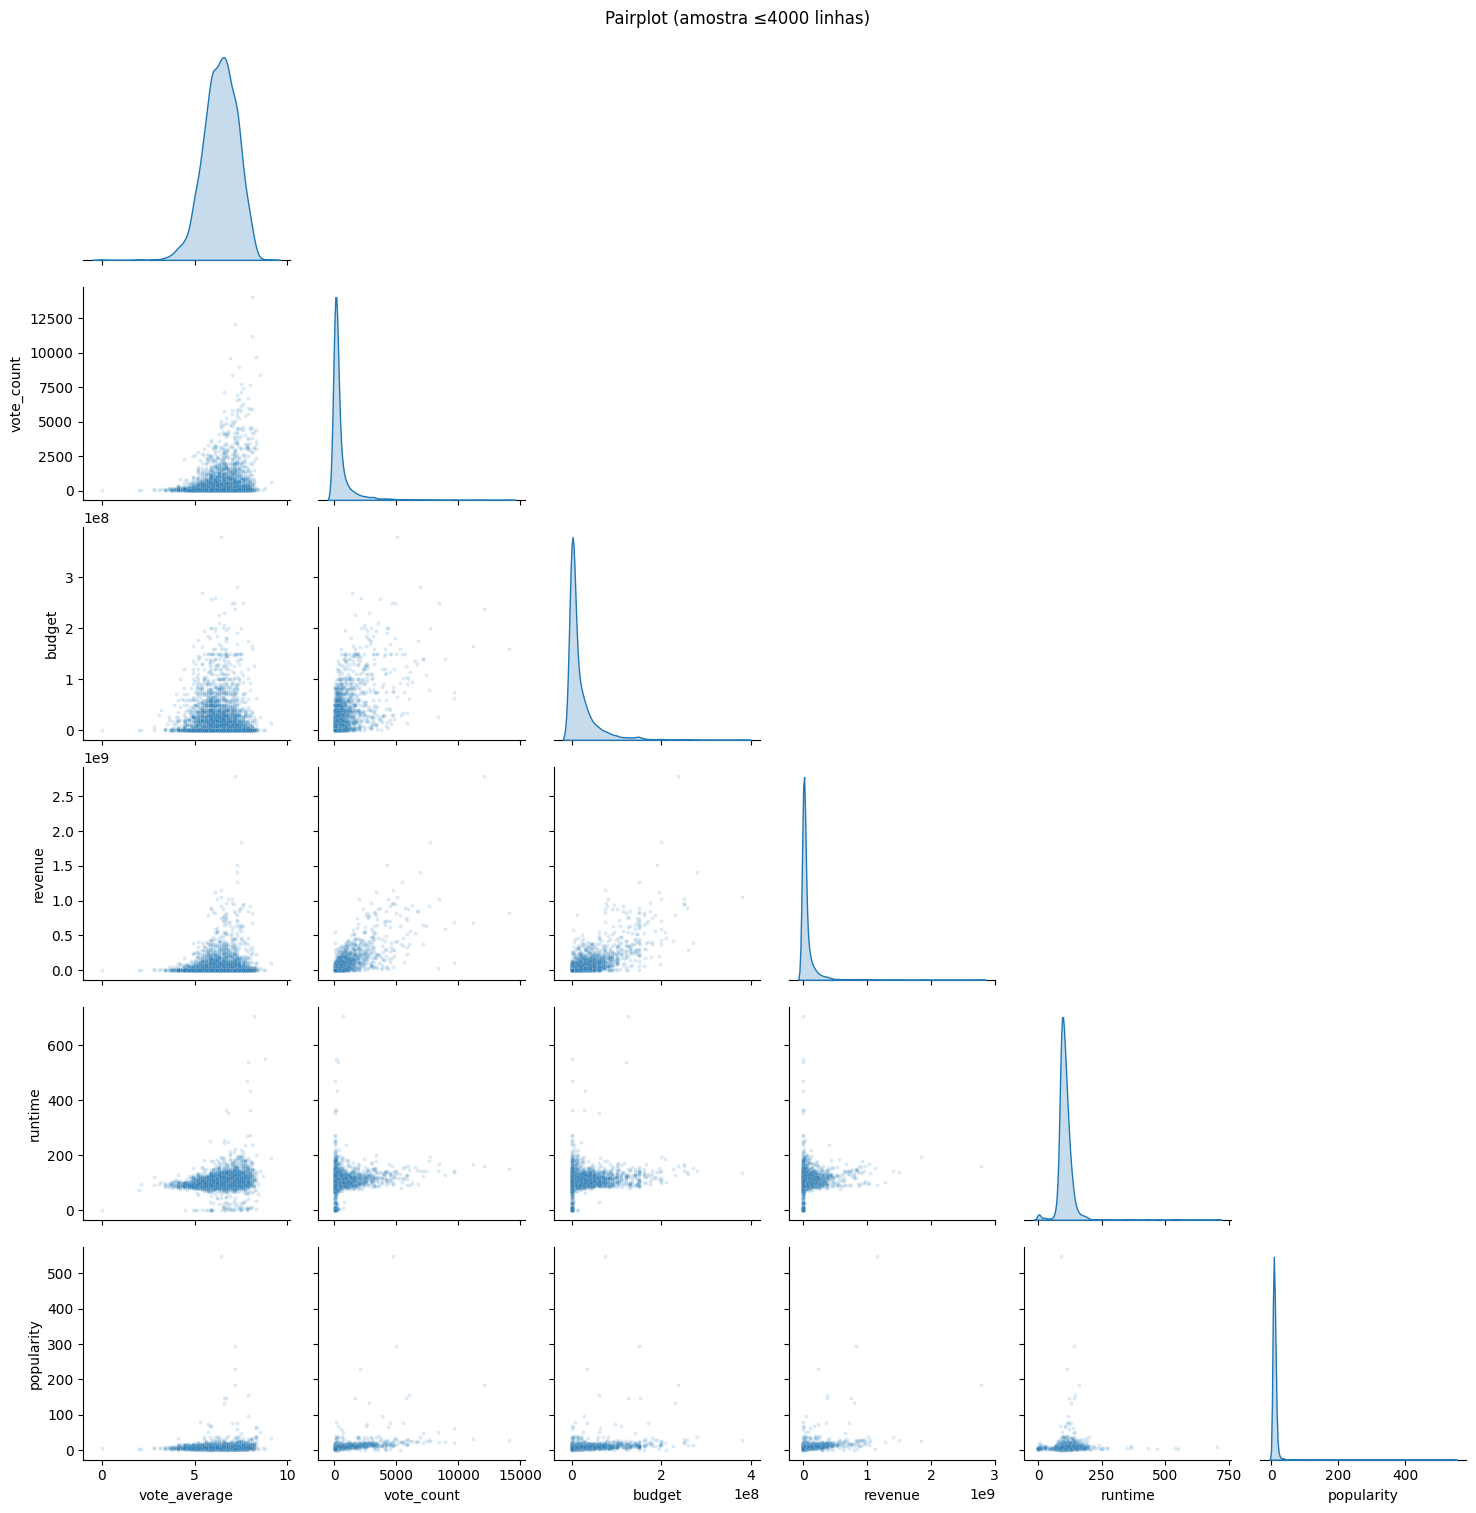

In [ ]:
pair_df = df_filtered[['vote_average', 'vote_count', 'budget', 'revenue', 'runtime', 'popularity']].copy()
pair_df = pair_df.apply(pd.to_numeric, errors='coerce').dropna(subset=['vote_average'])
pair_df = pair_df.sample(n=min(4000, len(pair_df)), random_state=42)

sns.pairplot(pair_df, corner=True, plot_kws={'alpha': 0.15, 's': 8}, diag_kind='kde')
plt.suptitle('Pairplot (amostra ≤4000 linhas)', y=1.01)
plt.show()


/var/folders/3s/0c70tlj57zd6hjlvvtwxz_h80000gp/T/ipykernel_95226/2281315539.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang, y='original_language', x='mean', palette='crest')


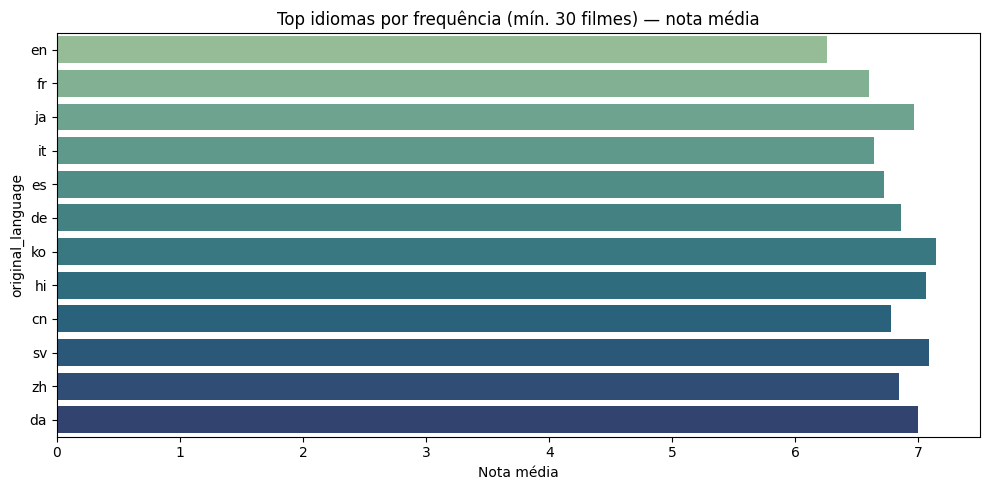

/var/folders/3s/0c70tlj57zd6hjlvvtwxz_h80000gp/T/ipykernel_95226/2281315539.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=co, y='_country', x='mean', palette='mako')


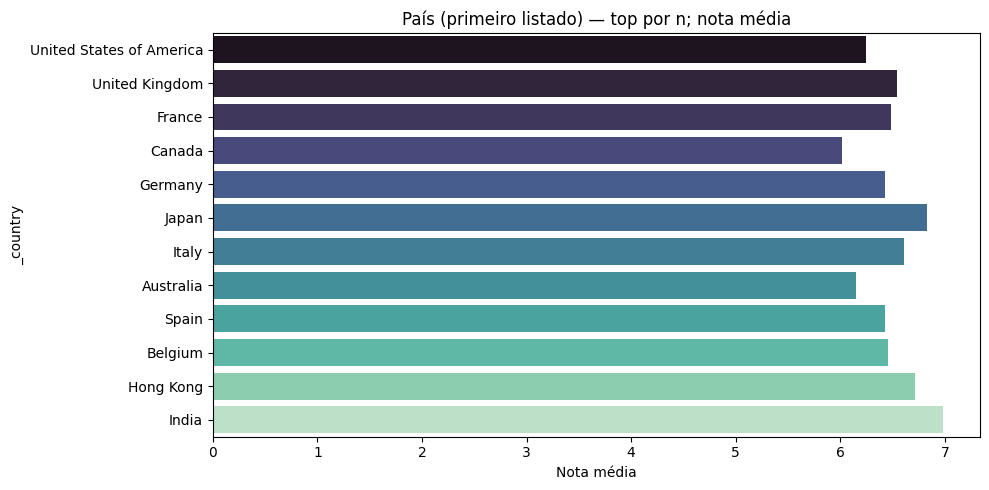

In [258]:
import numpy as np
import ast

# --- Categorias frequentes vs nota média (idioma, status, país principal) ---
cat_df = df_filtered.copy()
cat_df['vote_average'] = pd.to_numeric(cat_df['vote_average'], errors='coerce')

def top_n_mean(df_, col, n=12, min_count=30):
    g = df_.groupby(col)['vote_average'].agg(['mean', 'count']).reset_index()
    g = g[g['count'] >= min_count].sort_values('count', ascending=False).head(n)
    return g

if 'original_language' in cat_df.columns:
    lang = top_n_mean(cat_df, 'original_language', n=15)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=lang, y='original_language', x='mean', palette='crest')
    plt.xlabel('Nota média')
    plt.title('Top idiomas por frequência (mín. 30 filmes) — nota média')
    plt.tight_layout()
    plt.show()

def first_country(cell):
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return np.nan
    if isinstance(cell, str):
        try:
            cell = ast.literal_eval(cell)
        except (ValueError, SyntaxError):
            return np.nan
    if isinstance(cell, list) and len(cell):
        d = cell[0]
        return d.get('name', np.nan) if isinstance(d, dict) else np.nan
    return np.nan

if 'production_countries' in cat_df.columns:
    cat_df['_country'] = cat_df['production_countries'].apply(first_country)
    co = top_n_mean(cat_df.dropna(subset=['_country']), '_country', n=12)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=co, y='_country', x='mean', palette='mako')
    plt.xlabel('Nota média')
    plt.title('País (primeiro listado) — top por n; nota média')
    plt.tight_layout()
    plt.show()


In [260]:
df = df[df['director'] != 'Unknown'].copy()

In [261]:
print("\nQuantidade de filmes Unknown:")
print(len(df[df['director'] == 'Unknown']))


Quantidade de filmes Unknown:
0


### Dataset Modelo

In [262]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score


In [284]:
df.isna().sum()

movieId                      0
rating                       0
imdbId                       0
tmdbId                       0
adult                        0
belongs_to_collection    41620
budget                       0
genres                       0
homepage                 38189
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   978
popularity                   4
poster_path                386
production_companies         4
production_countries         4
release_date                86
revenue                      4
runtime                    265
spoken_languages             4
status                      84
tagline                  25570
title                        4
video                        4
vote_average                 4
vote_count                   4
cast                         0
crew                         0
keywords                     0
director                     0
dtype: i

In [163]:
def list_to_string(data):
    # Se for uma lista de strings, junta com vírgula. Se não, retorna string vazia.
    if isinstance(data, list) and len(data) > 0:
        return ", ".join([str(item) for item in data])
    return "unknown"

In [368]:
df_ml = df[df['vote_count'] > 50].copy()
df_ml['runtime'] = df_ml['runtime'].replace(0, np.nan)
df_ml['budget'] = pd.to_numeric(df_ml['budget'], errors='coerce').replace(0, np.nan)
df_ml = df_ml[df_ml['runtime'] > 0].copy()
df_ml = df_ml[df_ml['budget'] > 0].copy()
df_ml.dropna(subset=['vote_average', 'runtime'], inplace=True)

In [369]:
df_ml['genres_str'] = df_ml['genres'].apply(list_to_string)
df_ml['cast_str'] = df_ml['cast'].apply(list_to_string)
df_ml['keywords_str'] = df_ml['keywords'].apply(list_to_string)
df_ml['production_companies_str'] = df_ml['production_companies'].apply(list_to_string)
df_ml['production_countries_str'] = df_ml['production_countries'].apply(list_to_string)
df_ml['spoken_languages_str'] = df_ml['spoken_languages'].apply(list_to_string)
df_ml['production_countries_str'] = df_ml['production_countries'].apply(list_to_string)
df_ml['log_budget'] = np.log1p(df_ml['budget'])
df_ml['is_collection'] = df_ml['belongs_to_collection'].notna().astype(int)
df_ml['release_date'] = pd.to_datetime(df_ml['release_date'], errors='coerce')
df_ml['release_month'] = df_ml['release_date'].dt.month.fillna(0).astype(int)

In [288]:
df_ml['cast_str']

0                        Tom Hanks, Tim Allen, Don Rickles
1             Robin Williams, Jonathan Hyde, Kirsten Dunst
5                    Al Pacino, Robert De Niro, Val Kilmer
6                Harrison Ford, Julia Ormond, Greg Kinnear
8        Jean-Claude Van Damme, Powers Boothe, Dorian H...
                               ...                        
45833                T.J. Miller, James Corden, Anna Faris
45861       Jeremy Renner, Elizabeth Olsen, Gil Birmingham
45900               John Boyega, Will Poulter, Algee Smith
45968       Ramzy Bedia, Malik Bentalha, Franck Gastambide
46043          Jean Reno, Christian Clavier, Franck Dubosc
Name: cast_str, Length: 5435, dtype: object

### RandomForest

In [310]:
X = df_ml[['budget', 'runtime', 'original_language', 'production_companies_str', 'production_countries_str', 'spoken_languages_str']]
y = df_ml['vote_average']

In [311]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), 
            ['budget', 'runtime']),
        ('language', OneHotEncoder(handle_unknown='ignore'), 
            ['original_language']),
        ('companies', CountVectorizer(max_features=100), 'production_companies_str'),
        ('countries', CountVectorizer(max_features=50), 'production_countries_str'),
        ('spoken_langs', CountVectorizer(max_features=50), 'spoken_languages_str')
    ],
    remainder='passthrough'
)

In [312]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [313]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=500, max_depth=50, bootstrap=True, n_jobs=-1, random_state=42))
])

In [314]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('language', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the 

In [315]:
y_pred = model_pipeline.predict(X_test)

In [316]:
mae = mean_absolute_error(y_test, y_pred)
y_dummy = np.full_like(y_test, y_train.mean())
mae_dummy = mean_absolute_error(y_test, y_dummy)
r2 = r2_score(y_test, y_pred)

print(f"MAE do Modelo: {mae:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.2f}")
print(f"MAE se eu apenas chutasse a média: {mae_dummy:.2f}")
print(f"Melhoria real: {mae_dummy - mae:.2f} estrelas")

MAE do Modelo: 0.85
Coeficiente de Determinação (R²): -0.04
MAE se eu apenas chutasse a média: 0.86
Melhoria real: 0.00 estrelas


/var/folders/3s/0c70tlj57zd6hjlvvtwxz_h80000gp/T/ipykernel_95226/2246098040.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(20), palette='magma')


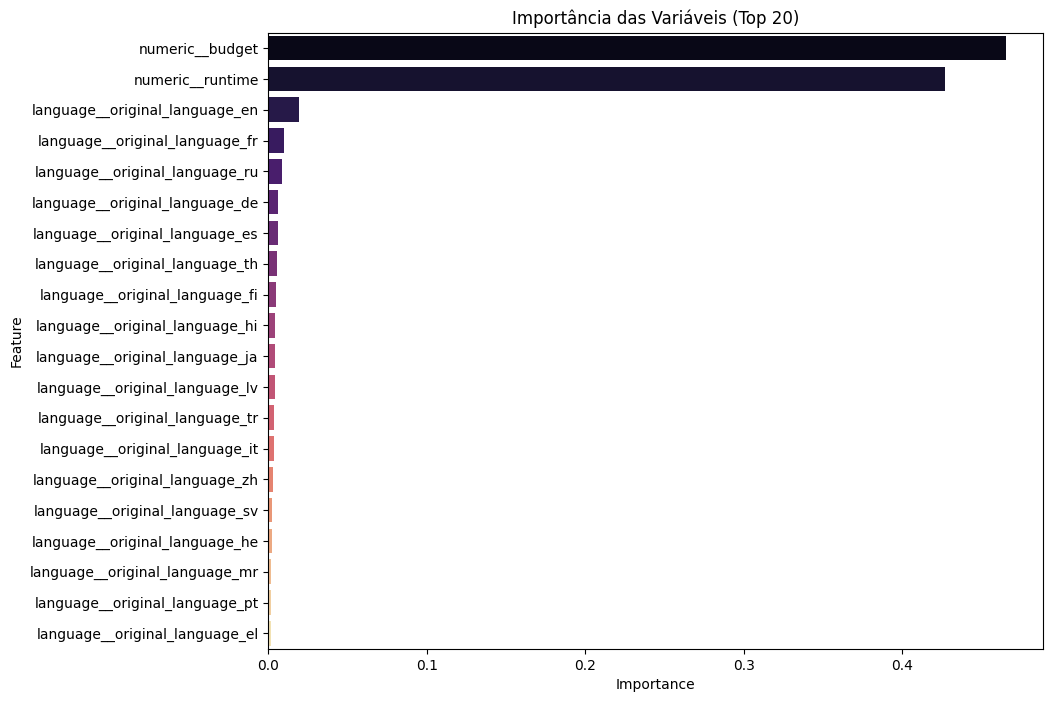

In [317]:
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = model_pipeline.named_steps['regressor'].feature_importances_

# 2. Organizar os dados
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plotar o Top 20
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(20), palette='magma')

plt.title('Importância das Variáveis (Top 20)')
plt.show()

In [69]:
feature_names

array(['numeric__director_score', 'numeric__budget', 'numeric__runtime',
       'numeric__cast_score', 'language__original_language_ab',
       'language__original_language_af', 'language__original_language_ar',
       'language__original_language_bn', 'language__original_language_bs',
       'language__original_language_cn', 'language__original_language_cs',
       'language__original_language_da', 'language__original_language_de',
       'language__original_language_el', 'language__original_language_en',
       'language__original_language_es', 'language__original_language_et',
       'language__original_language_fa', 'language__original_language_fi',
       'language__original_language_fr', 'language__original_language_he',
       'language__original_language_hi', 'language__original_language_hu',
       'language__original_language_id', 'language__original_language_is',
       'language__original_language_it', 'language__original_language_ja',
       'language__original_language_ko

### HistGradientBoostingRegressor

In [104]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from category_encoders import TargetEncoder


In [348]:
df_ml.columns

Index(['movieId', 'rating', 'imdbId', 'tmdbId', 'adult',
       'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count', 'cast', 'crew', 'keywords', 'director',
       'genres_str', 'cast_str', 'keywords_str', 'production_companies_str',
       'production_countries_str', 'spoken_languages_str', 'log_budget',
       'is_collection', 'release_month'],
      dtype='object')

In [321]:
df_ml['keywords_str']

0                                       jealousy, toy, boy
1        board game, disappearance, based on children's...
3        based on novel, interracial relationship, sing...
5                                 robbery, detective, bank
6           paris, brother brother relationship, chauffeur
                               ...                        
46102                                              unknown
46108                                       woman director
46109                                              unknown
46112                                              unknown
46122                                              unknown
Name: keywords_str, Length: 9035, dtype: object

In [390]:
features_numericas = ['runtime', 'log_budget']
cols_cat_nominais = ['release_month']
features_ordinais = [
    'director'
    ]
feature_texto = 'cast_str'

In [384]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numericas),
        ('cat_simple', OneHotEncoder(handle_unknown='ignore'), cols_cat_nominais),
        ('cat', TargetEncoder(smoothing=50.0), features_ordinais),
        ('cast', CountVectorizer(max_features=100, binary=True), feature_texto),
    ], sparse_threshold=0)
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('hgb', HistGradientBoostingRegressor(
        random_state=42, 
        max_iter=500
    ))
])

In [385]:
param_grid = {
    'hgb__learning_rate': [0.01, 0.05, 0.1],
    'hgb__max_iter': [100, 300, 500],
    'hgb__max_leaf_nodes': [10, 20, 31, 50],
    'hgb__min_samples_leaf': [20, 50]
}

X = df_ml[features_numericas + cols_cat_nominais + features_ordinais + [feature_texto]]
y = df_ml['vote_average']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

grid_search = GridSearchCV(pipe, param_grid, cv=10, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nMelhor R²: {grid_search.best_score_:.4f}")
print(f"Melhores parâmetros: {grid_search.best_params_}")

Fitting 10 folds for each of 72 candidates, totalling 720 fits

Melhor R²: 0.2247
Melhores parâmetros: {'hgb__learning_rate': 0.01, 'hgb__max_iter': 100, 'hgb__max_leaf_nodes': 50, 'hgb__min_samples_leaf': 20}


In [386]:
best_pipe = grid_search.best_estimator_
best_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('hgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_simple', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [392]:
y_pred = best_pipe.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Métrica customizada: % de acerto dentro de uma margem de 1.0 ponto
errors = np.abs(y_test - y_pred)
accuracy_margin = (errors < 1.0).mean()

print(f"MAE: {mae:.2f} (Erramos +- {mae:.2f} estrelas)")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"Precisão (margem 1.0): {accuracy_margin*100:.2f}%")

MAE: 0.59 (Erramos +- 0.59 estrelas)
RMSE: 0.74
R²: 0.2608
Precisão (margem 1.0): 83.16%


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

# 1. Calcular a importância no modelo de 0.27
# Usamos o X_test e y_test para ver como o modelo generaliza
result = permutation_importance(
    grid_search.best_estimator_, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1
)

# 2. Organizar os resultados
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

print("Confirmação de Impacto das Variáveis:")
print(feature_importance)

Confirmação de Impacto das Variáveis:
         feature  importance_mean  importance_std
0        runtime         0.218514        0.013827
4   keywords_str         0.086504        0.013321
1     log_budget         0.028190        0.005934
3       cast_str         0.006635        0.001848
2  release_month        -0.000100        0.003367
